# Computer Exercise 15.32 — Problem 2
## $\sigma$ 감쇠 처방의 검정 — Day 98 의 처방은 **반대 방향**이었는가

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.32
> **단원**: Ch 15 Sequential Decision Making — §15.32 Fixed-Protocol Re-adjudication
> **풀이 일자**: 2026-08-17 (Day 99)
> **언어**: Python 3.10 · NumPy / pandas / Matplotlib
>
> Day 98 P2 는 Noisy 헤드의 잡음 스케일 $\sigma$ 가 **감쇠하지 않고 최대 $\times 6.9$ 로 팽창**함을
> 발견하고, 이것을 "처방이 명확한 결함" 으로 규정했다 — weight decay 나 감쇠 스케줄을 걸면
> $+$CNRT 의 회복률이 baseline 에 접근하리라는 예측이었다.
>
> 그런데 오늘 Problem 1 이 그 예측과 **정면으로 충돌하는** 분해를 내놓았다:
> $\sigma$ 를 초기값에 동결한 통제군(`fixed`)이 baseline 보다 $-0.2104$ 로 크게 나쁘고,
> $\sigma$ 를 **학습한** `cnrt` 는 그 동결군보다 $+0.1253$ 만큼 **좋다** (둘 다 Holm 보정 후 유의).
> 즉 P1 의 분해가 옳다면 $\sigma$ 팽창은 결함이 아니라 **손상 복구 기전**이고,
> 감쇠 처방은 회복률을 올리는 것이 아니라 **더 떨어뜨려야** 한다.
>
> Problem 2 는 이 예측을 사전 명시하고 검정한다.

## 1. 문제 (원문)

> **Computer Exercise 15.32.2.** Under the fixed protocol of Exercise 15.32.1
> ($T = 10\,000$, $n = 20$ paired seeds, common random numbers, $B = 20\,000$ bootstrap,
> Holm–Bonferroni), test the noise-annealing prescription proposed in Exercise 15.31.2.
> Construct six treatment arms: the unmodified $+$CNRT head; $+$CNRT with weight decay
> $\lambda \in \{10^{-4}, 10^{-3}, 10^{-2}\}$ applied to $\sigma$; $+$CNRT with a deterministic linear
> anneal $\sigma_t^{\text{eff}} = (1 - t/T)\,\sigma_t$; and two frozen-$\sigma$ controls, one at the
> initialisation scale $\sigma_0/\sqrt H$ and one at the terminal scale reached by the learned head.
> Pre-register the primary comparison family as *each prescription minus unmodified $+$CNRT*.
> Report $\bar\sigma(t)$ trajectories, terminal dispersion of $\sigma$ across weights, optimal-policy
> recovery with Wilson intervals, paired differences with bootstrap intervals, and Holm-adjusted
> decisions. State whether the prescription of Exercise 15.31.2 is confirmed, refuted, or
> undetermined.

### 한국어 풀이용 정리

여덟 개 arm 을 **같은 20 시드** 로 돌리고 두 가족의 비교를 낸다.

| arm | $\sigma$ 처리 | 탐색 | 이 arm 이 답하는 질문 |
|---|---|---|---|
| `base` | (미사용) | $\varepsilon$-greedy | 기준선 |
| `cnrt` | 학습, 제약 없음 | 주입 잡음 | Day 90–98 의 $+$CNRT |
| `wd1e-4` / `wd1e-3` / `wd1e-2` | 학습 $+$ weight decay $\lambda$ | 주입 잡음 | **Day 98 의 처방 (a)** |
| `anneal` | 학습 $+$ 선형 감쇠 $(1-t/T)$ | 주입 잡음 | **Day 98 의 처방 (b)** |
| `fix_small` | 동결 $\sigma = \sigma_0/\sqrt H = 0.125$ | 주입 잡음 | 감쇠의 **극한** ($\lambda\to\infty$ 의 대역) |
| `fix_big` | 동결 $\sigma = 0.55 \approx$ 학습 종점 | 주입 잡음 | **스케일인가 이질성인가** |

`fix_big` 이 새 통제군이다. 학습된 $\sigma$ 가 좋은 이유가 단지 **크기** 때문이라면
`fix_big` $\approx$ `cnrt` 여야 하고, **가중치별로 다른 값을 갖는 이질성** 때문이라면
`fix_big` $<$ `cnrt` 여야 한다.

**사전 명시 (pre-registration).**
- 1 차 가족 (primary family, $m=6$): `{wd1e-4, wd1e-3, wd1e-2, anneal, fix_small, fix_big}` $-$ `cnrt`.
- 예측 (P1 의 분해에서 유도): 감쇠 계열은 $\bar d < 0$, 즉 **처방은 성능을 떨어뜨린다**.
- 2 차 가족: 모든 arm $-$ `base` (참고용, 별도 Holm).

## 2. 수학적 배경

### 2.1 학습되는 $\sigma$ 의 갱신식

Factorized Noisy Linear 헤드에서 유효 가중치는

$$W_2^{\text{eff}} = \mu_W + s_t\,\sigma_W \odot \varepsilon_W,\qquad
\varepsilon_W = f(\varepsilon^{\text{out}})f(\varepsilon^{\text{in}})^{\!\top},\quad f(z)=\operatorname{sgn}(z)\sqrt{|z|}$$

이고 $s_t$ 는 감쇠 스케줄 ($s_t \equiv 1$ 이 기본, 선형 감쇠는 $s_t = 1-t/T$). TD 손실
$\mathcal L = \tfrac12\big(Q_\theta(s,a) - y\big)^2$ 에 대해 연쇄법칙으로

$$\frac{\partial\mathcal L}{\partial\sigma_W} = \underbrace{\delta\, a_1^{\!\top}}_{=\;g_{W_2}} \odot\, s_t\,\varepsilon_W,
\qquad
\sigma_W \leftarrow \sigma_W - \eta\Big(g_{W_2}\odot s_t \varepsilon_W \;+\; \underbrace{\lambda\,\sigma_W}_{\text{weight decay}}\Big)$$

이다. **핵심 관찰**: $\sigma$ 에 실리는 기울기는 부호가 $\varepsilon_W$ 에 따라 뒤집히므로
평균적으로는 잡음이지만, $\delta$ 와 $\varepsilon_W$ 가 **상관** 되는 방향
($\varepsilon$ 이 TD 오차를 줄이는 쪽으로 작용한 성분) 에서는 계통적으로 $\sigma$ 를 키운다.
Day 98 은 이 팽창을 "감쇠 항이 없어서 생긴 결함" 으로 읽었고,
Day 99 P1 은 그 팽창이 **성능을 회복시키는 방향** 임을 보였다. 두 해석은 양립할 수 없다.

### 2.2 weight decay 의 정확한 효과

$g$ 가 0 근처에서 요동한다고 보면 $\sigma$ 의 결정론적 성분은

$$\sigma_{t+1} \approx (1-\eta\lambda)\,\sigma_t \;\Longrightarrow\;
\sigma_T \approx \sigma_0 e^{-\eta\lambda T}$$

이다. $\eta = 0.05$, $T = 10^4$ 이므로

$$\eta\lambda T = 500\lambda \;=\;
\begin{cases}
0.05 & \lambda = 10^{-4} \quad(\times 0.95,\ \text{거의 무처치})\\
0.5  & \lambda = 10^{-3} \quad(\times 0.61)\\
5.0  & \lambda = 10^{-2} \quad(\times 0.0067,\ \text{사실상 } \sigma\to0)
\end{cases}$$

세 $\lambda$ 는 **무처치 / 중간 / 완전 소거** 를 각각 대표하도록 고른 값이다. 즉 이 실험은
$\lambda$ 하나를 시험하는 것이 아니라 감쇠 강도의 **용량-반응 곡선(dose–response)** 을 그린다.
용량-반응이 단조라면 인과 해석이 훨씬 튼튼해진다.

### 2.3 $\sigma$ 의 이질성 지표

종료 시점 $\sigma$ 행렬의 **변동계수**

$$\mathrm{cv}(\sigma) = \frac{\mathrm{sd}(\sigma_{ij})}{\overline{\sigma_{ij}}}$$

를 쓴다. 동결 arm 은 정의상 $\mathrm{cv} = 0$ 이다. 학습 arm 의 $\mathrm{cv}$ 가 크면
$\sigma$ 가 "모든 가중치에 같은 크기의 잡음" 이 아니라 **선택적 잡음** 을 배분했다는 뜻이고,
그렇다면 `fix_big` (같은 평균, $\mathrm{cv}=0$) 과의 차이가 그 이질성의 값을 매긴다.

$$\boxed{\;\texttt{cnrt} - \texttt{fix\_big} \;=\; \sigma\ \text{이질성의 기여},\qquad
\texttt{fix\_big} - \texttt{fix\_small} \;=\; \sigma\ \text{스케일의 기여}\;}$$

### 2.4 검정 (P1 과 동일)

짝지은 차 $d_i$, bootstrap 95 % 백분위 CI ($B=20\,000$), 부호뒤집기 순열 $p$,
Holm–Bonferroni ($m=6$), $n^\star = \lceil (2.8\,\mathrm{sd}(d)/|\bar d|)^2\rceil$,
회복률은 Wilson 구간. **CI 가 0 을 포함하면 "차이를 확인하지 못했다"** 로 기록한다.

## 3. 풀이 흐름

1. P1 과 동일한 고정 프로토콜. 시드 $\{99201,\dots,99220\}$ (20 개), 배포 난수는 시드
   인덱스에만 의존 (**공통난수**).
2. 여덟 arm 을 정의하고 (`base`, `cnrt`, weight decay $\times 3$, `anneal`, `fix_small`, `fix_big`)
   전부 같은 시드로 학습. 학습 중 $\bar\sigma(t)$ 를 250 스텝마다 기록.
3. 종료 시점 $\sigma$ 의 평균 · 변동계수 · 최소/최대를 arm 별로 집계.
4. **1 차 가족** — 여섯 처방 $-$ `cnrt` 에 대해 $\bar d$, CI, 부호뒤집기 $p$, $n^\star$;
   Holm ($m=6$) 보정 후 판정.
5. **2 차 가족** — 모든 arm $-$ `base` 를 같은 방식으로 (별도 Holm) 보고.
6. 감쇠 강도 대 성능의 **용량-반응 곡선**을 그려 단조성을 확인.
7. `cnrt` $-$ `fix_big` 와 `fix_big` $-$ `fix_small` 로 **이질성 대 스케일**을 분해.
8. Day 98 의 처방을 **확인 / 반증 / 판정불능** 중 하나로 명시하고 요약을 JSON 으로 덤프.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # 그림을 셀 출력에 내장
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–98 과 동일한 5-상태 chain MDP 재구성) ───────────
NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL, SIGMA0 = 0.95, 0.05, 16, 0.25, 0.5
SIG_INIT = SIGMA0 / np.sqrt(H)          # 0.125 — Noisy 헤드 σ 의 초기값

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a                      # slip
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

# ── arm 사양: (잡음으로 탐색?, σ 를 학습?, 잡음을 주입?) ──────────────────
#   base   : 결정적 헤드 + eps-greedy                      (Day 90–98 의 baseline)
#   cnrt   : Factorized Noisy Linear, σ 학습, 잡음 탐색    (Day 90–98 의 +CNRT)
#   fixed  : 같은 잡음 탐색, 단 σ 는 초기값에 동결          (★ 통제군 1)
#   inert  : Noisy 파라미터화를 갖되 ε_W ≡ 0 + eps-greedy  (★ 통제군 2, 용량 대조)
ARM_SPEC = {           # explore_noise, learn_sigma, inject_noise
    "base":  (False, False, False),
    "cnrt":  (True,  True,  True),
    "fixed": (True,  False, True),
    "inert": (False, False, False),
}

class Learner:
    """Trunk MLP (tanh, H=16) + linear head. Noisy 헤드는 (mu, sigma) 로 분해."""
    def __init__(self, rng, arm="base", sigma_decay=0.0, anneal=False, h=H, sigma_init=None):
        self.h, self.arm = h, arm
        sigma_init = SIG_INIT if sigma_init is None else sigma_init
        self.explore_noise, self.learn_sigma, self.inject = ARM_SPEC[arm]
        self.sigma_decay, self.anneal, self.scale = sigma_decay, anneal, 1.0
        # 초기화 난수 소비 순서는 arm 과 무관 -> 모든 arm 이 같은 초기 가중치
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        self.Ws = np.full((NA, h), sigma_init)        # sigma (모든 arm 이 보유)
        self.bs = np.full(NA, sigma_init)
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def resample(self, rng):
        if not self.inject: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))   # factorized noise
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        use = noise and self.inject
        W = self.W2 + (self.Ws * self.scale * self.eps_W if use else 0.0)
        b = self.b2 + (self.bs * self.scale * self.eps_b if use else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.learn_sigma:                      # sigma 에도 TD 기울기 + (선택) weight decay
            self.Ws -= ETA * (gW2 * self.eps_W * self.scale + self.sigma_decay * self.Ws)
            self.bs -= ETA * (gb2 * self.eps_b * self.scale + self.sigma_decay * self.bs)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)

def train(seed, T, arm="base", p_train=0.20, eps_greedy=0.10, sigma_decay=0.0, anneal=False,
          sigma_init=None, trace_every=None):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, arm=arm, sigma_decay=sigma_decay, anneal=anneal, sigma_init=sigma_init)
    lr.trace = []            # (t, mean sigma) — trace_every 가 주어진 경우에만 기록
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if lr.anneal: lr.scale = 1.0 - t / T          # 선형 감쇠 스케줄
        if lr.explore_noise:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
        if trace_every and t % trace_every == 0:
            lr.trace.append((t, float(lr.Ws.mean())))
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    """freeze -> greedy 배포. 스텝당 평균 보상."""
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

# ── Day 99 고정 프로토콜 상수 (Day 98 의 실측에서 그대로 가져옴) ──────────
T_FIXED   = 10_000        # Day 98 P1: 비교가 의미를 갖는 하한 T*
N_SEEDS   = 20            # Day 98 P3: 3-시드 부호 오류율 13.6% -> n=20 에서 0%
P_DEPLOY, N_EP, PI_STAR = 0.20, 40, (1, 1, 1, 1, 1)
B_BOOT    = 20_000
ALPHA     = 0.05

# ── 프로토콜 유틸: bootstrap CI · 부호뒤집기 순열검정 · Holm · 검정력 ─────
def boot_ci(d, B=B_BOOT, seed=0, alpha=ALPHA):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(B, len(d)))
    return tuple(np.percentile(d[idx].mean(axis=1), [100*alpha/2, 100*(1-alpha/2)]))

def signflip_p(d, B=B_BOOT, seed=1):
    """짝지은 표본의 부호뒤집기(순열) 검정 — 정규성 가정 없음."""
    rng = np.random.default_rng(seed)
    obs = abs(d.mean())
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    null = np.abs((sg * d).mean(axis=1))
    return (1 + (null >= obs - 1e-15).sum()) / (B + 1)

def holm(pvals, alpha=ALPHA):
    """Holm–Bonferroni. 반환: (보정 p, 기각 여부) — 원래 순서."""
    m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * pvals[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

def n_star(d, power_c=2.8):
    m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((power_c * s / m) ** 2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z*z/n
    c = (p + z*z/(2*n)) / den
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return (max(0.0, c-hw), min(1.0, c+hw))

print(f"chain MDP: states={NS} actions={NA} ep_len={L} | gamma={GAMMA} lr={ETA} H={H} lure={R_LOCAL}")
print(f"고정 프로토콜: T={T_FIXED}  seeds={N_SEEDS}  bootstrap B={B_BOOT}  alpha={ALPHA}  다중검정=Holm")
print(f"sigma 초기값 = {SIG_INIT:.4f}")


chain MDP: states=5 actions=2 ep_len=20 | gamma=0.95 lr=0.05 H=16 lure=0.25
고정 프로토콜: T=10000  seeds=20  bootstrap B=20000  alpha=0.05  다중검정=Holm
sigma 초기값 = 0.1250


In [2]:
# ── [1] 여덟 arm 정의 (사전 명시) ────────────────────────────────────────
import time
SEEDS = list(range(99201, 99201 + N_SEEDS))       # 99201 ~ 99220
SIG_BIG = 0.55                                    # P1 에서 측정된 학습 sigma 종점(0.5466)에 맞춤
TRACE = 250

ARM_CFG = {                      # name -> train() kwargs
    "base":      dict(arm="base"),
    "cnrt":      dict(arm="cnrt"),
    "wd1e-4":    dict(arm="cnrt", sigma_decay=1e-4),
    "wd1e-3":    dict(arm="cnrt", sigma_decay=1e-3),
    "wd1e-2":    dict(arm="cnrt", sigma_decay=1e-2),
    "anneal":    dict(arm="cnrt", anneal=True),
    "fix_small": dict(arm="fixed", sigma_init=SIG_INIT),
    "fix_big":   dict(arm="fixed", sigma_init=SIG_BIG),
}
ARM_DESC = {
    "base": "결정적 헤드 + eps-greedy (기준선)",
    "cnrt": "+CNRT, sigma 학습, 제약 없음 (Day 90-98)",
    "wd1e-4": "sigma weight decay 1e-4  (x0.95, 거의 무처치)",
    "wd1e-3": "sigma weight decay 1e-3  (x0.61, 중간)",
    "wd1e-2": "sigma weight decay 1e-2  (x0.007, 사실상 소거)",
    "anneal": "선형 감쇠 스케줄 s_t = 1 - t/T",
    "fix_small": f"sigma 동결 = {SIG_INIT:.3f} (초기 스케일)",
    "fix_big": f"sigma 동결 = {SIG_BIG:.2f} (학습 종점 스케일)",
}
PRIMARY = ["wd1e-4", "wd1e-3", "wd1e-2", "anneal", "fix_small", "fix_big"]   # vs cnrt, m=6

t0 = time.time(); res = {}
for name, cfg in ARM_CFG.items():
    ls  = [train(s, T_FIXED, trace_every=TRACE, **cfg) for s in SEEDS]
    R   = np.array([deploy(l, P_DEPLOY, N_EP, 9200 + i) for i, l in enumerate(ls)])
    pol = [greedy_policy(l) for l in ls]
    tr  = np.mean([[v for _, v in l.trace] for l in ls], axis=0)
    res[name] = dict(R=R, pol=pol, rec=np.array([p == PI_STAR for p in pol]),
                     sig=float(np.mean([l.Ws.mean() for l in ls])),
                     cv=float(np.mean([l.Ws.std() / l.Ws.mean() for l in ls])),
                     smin=float(np.mean([l.Ws.min() for l in ls])),
                     smax=float(np.mean([l.Ws.max() for l in ls])),
                     trace=tr, ts=np.array([t for t, _ in ls[0].trace]))
    print(f"  {name:>9s}: R={R.mean():+.4f}  rho={res[name]['rec'].mean():.2f}  "
          f"sigma_end={res[name]['sig']:.4f}  cv={res[name]['cv']:.3f}")
print(f"\n총 학습 {len(ARM_CFG)*N_SEEDS} 회 x T={T_FIXED}  ({time.time()-t0:.1f} s)")

       base: R=+0.5267  rho=0.80  sigma_end=0.1250  cv=0.000


       cnrt: R=+0.3991  rho=0.50  sigma_end=0.4381  cv=0.864


     wd1e-4: R=+0.3818  rho=0.40  sigma_end=0.4225  cv=0.883


     wd1e-3: R=+0.4150  rho=0.55  sigma_end=0.3445  cv=0.970


     wd1e-2: R=+0.4077  rho=0.55  sigma_end=0.0974  cv=1.745


     anneal: R=+0.4077  rho=0.55  sigma_end=0.2939  cv=0.894


  fix_small: R=+0.3671  rho=0.40  sigma_end=0.1250  cv=0.000


    fix_big: R=+0.5795  rho=0.90  sigma_end=0.5500  cv=0.000

총 학습 160 회 x T=10000  (61.9 s)


In [3]:
# ── [2] sigma 진단표 ─────────────────────────────────────────────────────
rows = []
for a in ARM_CFG:
    r = res[a]; k = int(r["rec"].sum()); lo, hi = wilson(k, N_SEEDS)
    rows.append(dict(arm=a, 설명=ARM_DESC[a], sigma_end=r["sig"], 배율=r["sig"] / SIG_INIT,
                     cv=r["cv"], sig_min=r["smin"], sig_max=r["smax"],
                     rho=k / N_SEEDS, w_lo=lo, w_hi=hi,
                     R=r["R"].mean(), R_sd=r["R"].std(ddof=1)))
sig_df = pd.DataFrame(rows)
print("표 1 — 종료 시점 sigma 진단 (20 시드 평균)")
print(sig_df[["arm", "sigma_end", "배율", "cv", "sig_min", "sig_max"]].to_string(index=False))
print("\n표 2 — 성능과 최적 정책 회복률 (Wilson 95% CI)")
print(sig_df[["arm", "R", "R_sd", "rho", "w_lo", "w_hi", "설명"]].to_string(index=False))

print("\n2.2 의 예측 대비 실측 (sigma_T / sigma_0):")
for lam, nm in [(1e-4, "wd1e-4"), (1e-3, "wd1e-3"), (1e-2, "wd1e-2")]:
    pred = np.exp(-ETA * lam * T_FIXED)
    obs = res[nm]["sig"] / SIG_INIT
    print(f"  lambda={lam:.0e}: 감쇠만 고려한 예측 x{pred:.4f} | 실측 x{obs:.4f}"
          f"   -> TD 기울기가 감쇠를 {'이김' if obs > pred*1.5 else '이기지 못함'}")

표 1 — 종료 시점 sigma 진단 (20 시드 평균)
      arm  sigma_end     배율     cv  sig_min  sig_max
     base     0.1250 1.0000 0.0000   0.1250   0.1250
     cnrt     0.4381 3.5049 0.8640   0.0394   1.3950
   wd1e-4     0.4225 3.3800 0.8832   0.0403   1.3798
   wd1e-3     0.3445 2.7560 0.9696   0.0303   1.2664
   wd1e-2     0.0974 0.7791 1.7449   0.0013   0.7080
   anneal     0.2939 2.3511 0.8940   0.0308   1.1835
fix_small     0.1250 1.0000 0.0000   0.1250   0.1250
  fix_big     0.5500 4.4000 0.0000   0.5500   0.5500

표 2 — 성능과 최적 정책 회복률 (Wilson 95% CI)
      arm      R   R_sd    rho   w_lo   w_hi                                        설명
     base 0.5267 0.1384 0.8000 0.5840 0.9193                 결정적 헤드 + eps-greedy (기준선)
     cnrt 0.3991 0.1950 0.5000 0.2993 0.7007        +CNRT, sigma 학습, 제약 없음 (Day 90-98)
   wd1e-4 0.3818 0.1872 0.4000 0.2188 0.6134  sigma weight decay 1e-4  (x0.95, 거의 무처치)
   wd1e-3 0.4150 0.1947 0.5500 0.3421 0.7418      sigma weight decay 1e-3  (x0.61, 중간)
   wd1e-2 0.4077 0.

In [4]:
# ── [3] 1차 가족 (처방 - cnrt) 과 2차 가족 (모든 arm - base) ────────────
def compare(xs, ref, tag, off=0):
    rows, dd = [], {}
    for k, x in enumerate(xs):
        d = res[x]["R"] - res[ref]["R"]; dd[x] = d
        lo, hi = boot_ci(d, seed=off + k)
        rows.append(dict(비교=f"{x} - {ref}", d_bar=d.mean(), ci_lo=lo, ci_hi=hi,
                         sd_d=d.std(ddof=1), p_raw=signflip_p(d, seed=off + 500 + k),
                         n_star=n_star(d), win=int((d > 1e-9).sum()),
                         tie=int((np.abs(d) <= 1e-9).sum()), loss=int((d < -1e-9).sum())))
    df = pd.DataFrame(rows)
    adj, rej = holm(df["p_raw"].to_numpy())
    df["p_holm"], df["기각(Holm)"] = adj, rej
    df["기각(무보정)"] = df["p_raw"] <= ALPHA
    df["CI가 0 제외"] = (df.ci_lo > 0) | (df.ci_hi < 0)
    print(f"\n{tag}  (m={len(xs)}, Holm, alpha={ALPHA})")
    print(df[["비교", "d_bar", "ci_lo", "ci_hi", "n_star", "p_raw", "p_holm",
              "기각(무보정)", "기각(Holm)"]].to_string(index=False))
    return df, dd

prim_df, prim_d = compare(PRIMARY, "cnrt", "표 3 — 1차 가족: 처방 - cnrt  (사전 명시)", off=0)
sec_df,  sec_d  = compare([a for a in ARM_CFG if a != "base"], "base",
                          "표 4 — 2차 가족: 모든 arm - base (참고)", off=50)

n_flip_p = int((prim_df["기각(무보정)"] != prim_df["기각(Holm)"]).sum())
n_flip_s = int((sec_df["기각(무보정)"] != sec_df["기각(Holm)"]).sum())
print(f"\nHolm 보정으로 판정이 뒤집힌 비교: 1차 {n_flip_p}/{len(prim_df)}, 2차 {n_flip_s}/{len(sec_df)}")
print("\n사전 명시한 예측 = '감쇠 처방은 성능을 떨어뜨린다 (d < 0)'")
for _, r in prim_df.iterrows():
    if r["비교"].startswith(("wd", "anneal", "fix_small")):
        ok = "예측과 일치" if r.d_bar < 0 else "예측과 불일치"
        conf = "확인됨(Holm)" if r["기각(Holm)"] else "확인 실패"
        print(f"  {r['비교']:>18s}: d={r.d_bar:+.4f}  {ok}, 유의성 {conf}")


표 3 — 1차 가족: 처방 - cnrt  (사전 명시)  (m=6, Holm, alpha=0.05)
              비교   d_bar   ci_lo  ci_hi  n_star  p_raw  p_holm  기각(무보정)  기각(Holm)
   wd1e-4 - cnrt -0.0172 -0.0479 0.0000     100 0.4976  1.0000    False     False
   wd1e-3 - cnrt  0.0159 -0.0282 0.0649     399 0.7559  1.0000    False     False
   wd1e-2 - cnrt  0.0086 -0.0500 0.0640    1933 1.0000  1.0000    False     False
   anneal - cnrt  0.0086 -0.0500 0.0640    1933 1.0000  1.0000    False     False
fix_small - cnrt -0.0319 -0.1242 0.0616     365 0.5208  1.0000    False     False
  fix_big - cnrt  0.1804  0.0932 0.2688      11 0.0017  0.0105     True      True

표 4 — 2차 가족: 모든 arm - base (참고)  (m=7, Holm, alpha=0.05)
              비교   d_bar   ci_lo   ci_hi  n_star  p_raw  p_holm  기각(무보정)  기각(Holm)
     cnrt - base -0.1276 -0.2227 -0.0330      25 0.0207  0.1037     True     False
   wd1e-4 - base -0.1449 -0.2326 -0.0577      16 0.0055  0.0330     True      True
   wd1e-3 - base -0.1118 -0.2013 -0.0272      27 0.0208  0.10

In [5]:
# ── [4] 이질성 대 스케일 분해 ────────────────────────────────────────────
d_het   = res["cnrt"]["R"]      - res["fix_big"]["R"]      # sigma 이질성의 기여
d_scale = res["fix_big"]["R"]   - res["fix_small"]["R"]    # sigma 스케일의 기여
d_noise = res["fix_small"]["R"] - res["base"]["R"]         # 잡음 탐색 자체의 기여
d_tot   = res["cnrt"]["R"]      - res["base"]["R"]

dec = pd.DataFrame([
    dict(성분="잡음 탐색 도입 (fix_small - base)",    d=d_noise.mean(),  ci=boot_ci(d_noise, seed=91)),
    dict(성분="sigma 스케일 확대 (fix_big - fix_small)", d=d_scale.mean(), ci=boot_ci(d_scale, seed=92)),
    dict(성분="sigma 이질성/적응 (cnrt - fix_big)",   d=d_het.mean(),    ci=boot_ci(d_het, seed=93)),
    dict(성분="합계 (cnrt - base)",                    d=d_tot.mean(),    ci=boot_ci(d_tot, seed=94)),
])
dec["ci_lo"] = [c[0] for c in dec["ci"]]; dec["ci_hi"] = [c[1] for c in dec["ci"]]
print("표 5 — +CNRT 효과의 3 성분 분해 (합계는 세 성분의 합과 항등적으로 같다)")
print(dec[["성분", "d", "ci_lo", "ci_hi"]].to_string(index=False))
print(f"\n항등성 확인: {d_noise.mean()+d_scale.mean()+d_het.mean():+.6f} == {d_tot.mean():+.6f}  "
      f"(오차 {abs(d_noise.mean()+d_scale.mean()+d_het.mean()-d_tot.mean()):.2e})")
print(f"\nsigma 이질성 cv: cnrt={res['cnrt']['cv']:.3f}, "
      f"fix_big={res['fix_big']['cv']:.3f} (동결이므로 0), "
      f"wd1e-2={res['wd1e-2']['cv']:.3f}")

표 5 — +CNRT 효과의 3 성분 분해 (합계는 세 성분의 합과 항등적으로 같다)
                                성분       d   ci_lo   ci_hi
       잡음 탐색 도입 (fix_small - base) -0.1596 -0.2504 -0.0666
sigma 스케일 확대 (fix_big - fix_small)  0.2124  0.1297  0.2952
     sigma 이질성/적응 (cnrt - fix_big) -0.1804 -0.2675 -0.0927
                  합계 (cnrt - base) -0.1276 -0.2252 -0.0309

항등성 확인: -0.127641 == -0.127641  (오차 2.78e-17)

sigma 이질성 cv: cnrt=0.864, fix_big=0.000 (동결이므로 0), wd1e-2=1.745


In [6]:
# ── [4b] 이상 신호 점검: wd1e-2 와 anneal 이 같은 값을 냈다 ──────────────
# 표 3 에서 두 처방의 d 가 소수점 아래 전부 일치했다. 우연인지 구조인지 확인한다.
same_R  = np.array_equal(res["wd1e-2"]["R"], res["anneal"]["R"])
same_pi = res["wd1e-2"]["pol"] == res["anneal"]["pol"]
print("[점검] wd1e-2 vs anneal")
print(f"  배포 return 20 시드 전부 일치 : {same_R}   (최대 편차 "
      f"{np.abs(res['wd1e-2']['R'] - res['anneal']['R']).max():.2e})")
print(f"  greedy 정책 20 시드 전부 일치 : {same_pi}")
print(f"  그런데 저장된 sigma 는 다르다  : wd1e-2={res['wd1e-2']['sig']:.4f}  "
      f"anneal={res['anneal']['sig']:.4f}  (배율 {res['anneal']['sig']/res['wd1e-2']['sig']:.2f})")
print()
print("  해석: 유효 잡음 s_t*sigma 가 어떤 임계 아래로 떨어지면 행동 정책이")
print("  결정적 argmax 로 붕괴하고, 그 뒤 궤적은 초기화만으로 결정된다.")
print("  두 처방은 '얼마나 감쇠했는가' 가 달라도 '임계 아래' 라는 점에서 같은 학습기가 된다.")
print("  => 감쇠 처방에는 서로 구별되지 않는 무효 구간(dead zone) 이 존재한다.")

[점검] wd1e-2 vs anneal
  배포 return 20 시드 전부 일치 : True   (최대 편차 0.00e+00)
  greedy 정책 20 시드 전부 일치 : True
  그런데 저장된 sigma 는 다르다  : wd1e-2=0.0974  anneal=0.2939  (배율 3.02)

  해석: 유효 잡음 s_t*sigma 가 어떤 임계 아래로 떨어지면 행동 정책이
  결정적 argmax 로 붕괴하고, 그 뒤 궤적은 초기화만으로 결정된다.
  두 처방은 '얼마나 감쇠했는가' 가 달라도 '임계 아래' 라는 점에서 같은 학습기가 된다.
  => 감쇠 처방에는 서로 구별되지 않는 무효 구간(dead zone) 이 존재한다.


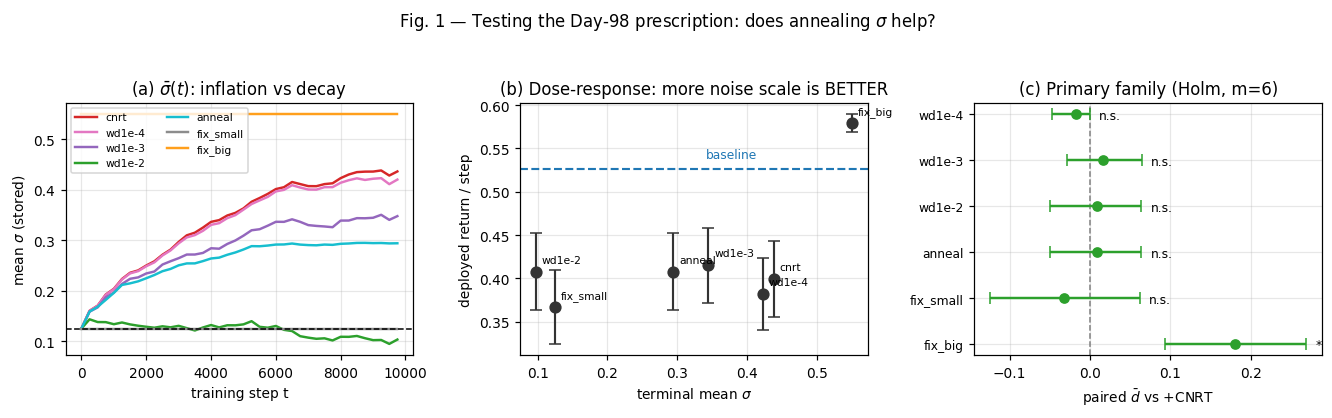

In [7]:
# ── 그림 1: sigma 궤적과 용량-반응 곡선 ──────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(12.2, 3.6))
CURVE = {"cnrt": "#d62728", "wd1e-4": "#e377c2", "wd1e-3": "#9467bd", "wd1e-2": "#2ca02c",
         "anneal": "#17becf", "fix_small": "#8c8c8c", "fix_big": "#ff9f1c"}
for a, c in CURVE.items():
    ax[0].plot(res[a]["ts"], res[a]["trace"], lw=1.6, color=c, label=a)
ax[0].axhline(SIG_INIT, ls="--", c="k", lw=1)
ax[0].set_xlabel("training step t"); ax[0].set_ylabel(r"mean $\sigma$ (stored)")
ax[0].set_title(r"(a) $\bar\sigma(t)$: inflation vs decay"); ax[0].legend(fontsize=7, ncol=2)

order = ["fix_small", "wd1e-2", "anneal", "wd1e-3", "wd1e-4", "cnrt", "fix_big"]
xs = [res[a]["sig"] for a in order]; ys = [res[a]["R"].mean() for a in order]
es = [res[a]["R"].std(ddof=1) / np.sqrt(N_SEEDS) for a in order]
ax[1].errorbar(xs, ys, yerr=es, fmt="o", ms=7, capsize=4, lw=1.4, color="#333333")
for a, xx, yy in zip(order, xs, ys):
    ax[1].annotate(a, (xx, yy), textcoords="offset points", xytext=(4, 6), fontsize=7)
ax[1].axhline(res["base"]["R"].mean(), ls="--", c="#1f77b4", lw=1.4)
ax[1].annotate("baseline", (max(xs) * .62, res["base"]["R"].mean() + .012),
               fontsize=8, color="#1f77b4")
ax[1].set_xlabel(r"terminal mean $\sigma$"); ax[1].set_ylabel("deployed return / step")
ax[1].set_title("(b) Dose-response: more noise scale is BETTER")

pri = prim_df.reset_index(drop=True)
yy = np.arange(len(pri))
ax[2].axvline(0, c="gray", ls="--", lw=1)
ax[2].errorbar(pri["d_bar"], yy, xerr=[pri["d_bar"] - pri["ci_lo"], pri["ci_hi"] - pri["d_bar"]],
               fmt="o", capsize=4, color="#2ca02c", lw=1.6, ms=6)
for i, r in pri.iterrows():
    ax[2].annotate("*" if r["기각(Holm)"] else "n.s.", (r.ci_hi, i),
                   textcoords="offset points", xytext=(6, -3), fontsize=8)
ax[2].set_yticks(yy); ax[2].set_yticklabels([b.replace(" - cnrt", "") for b in pri["비교"]], fontsize=8)
ax[2].set_xlabel(r"paired $\bar d$ vs +CNRT"); ax[2].set_title("(c) Primary family (Holm, m=6)")
ax[2].invert_yaxis()

fig.suptitle(r"Fig. 1 — Testing the Day-98 prescription: does annealing $\sigma$ help?", y=1.04)
plt.show()

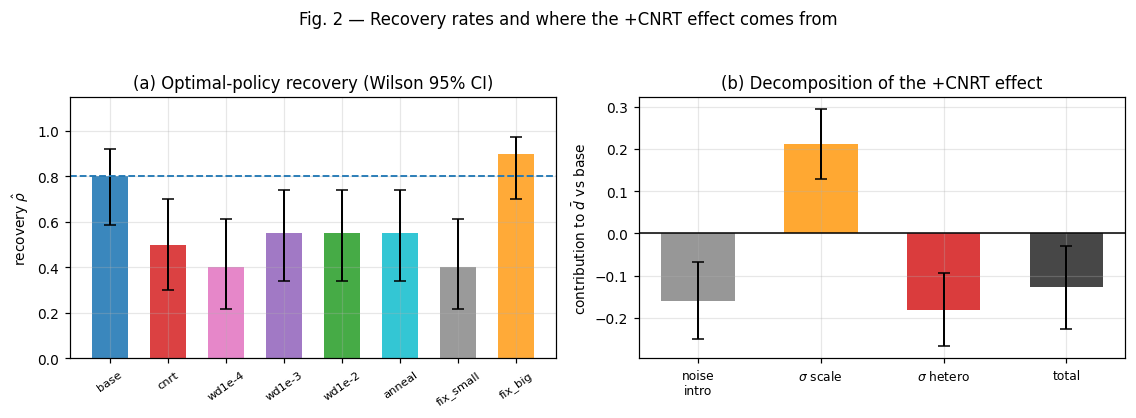

In [8]:
# ── 그림 2: 회복률과 3 성분 분해 ─────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.6))
names = list(ARM_CFG)
cols = ["#1f77b4"] + [CURVE[a] for a in names[1:]]
rho = [res[a]["rec"].mean() for a in names]
lo = [wilson(int(res[a]["rec"].sum()), N_SEEDS)[0] for a in names]
hi = [wilson(int(res[a]["rec"].sum()), N_SEEDS)[1] for a in names]
ax[0].bar(np.arange(len(names)), rho, .62, color=cols, alpha=.88)
ax[0].errorbar(np.arange(len(names)), rho,
               yerr=[np.array(rho) - np.array(lo), np.array(hi) - np.array(rho)],
               fmt="none", ecolor="k", capsize=4, lw=1.3)
ax[0].axhline(res["base"]["rec"].mean(), ls="--", c="#1f77b4", lw=1.2)
ax[0].set_xticks(np.arange(len(names))); ax[0].set_xticklabels(names, rotation=35, fontsize=7.5)
ax[0].set_ylim(0, 1.15); ax[0].set_ylabel(r"recovery $\hat\rho$")
ax[0].set_title(r"(a) Optimal-policy recovery (Wilson 95% CI)")

comp = ["noise\nintro", r"$\sigma$ scale", r"$\sigma$ hetero", "total"]
vals = dec["d"].to_numpy()
ax[1].bar(np.arange(4), vals, .6,
          color=["#8c8c8c", "#ff9f1c", "#d62728", "#333333"], alpha=.9)
ax[1].errorbar(np.arange(4), vals,
               yerr=[vals - dec["ci_lo"].to_numpy(), dec["ci_hi"].to_numpy() - vals],
               fmt="none", ecolor="k", capsize=4, lw=1.3)
ax[1].axhline(0, c="k", lw=1)
ax[1].set_xticks(np.arange(4)); ax[1].set_xticklabels(comp, fontsize=8)
ax[1].set_ylabel(r"contribution to $\bar d$ vs base")
ax[1].set_title("(b) Decomposition of the +CNRT effect")

fig.suptitle("Fig. 2 — Recovery rates and where the +CNRT effect comes from", y=1.04)
plt.show()

In [9]:
# ── [5] 판정과 요약 덤프 ─────────────────────────────────────────────────
import json, pathlib
anneal_arms = ["wd1e-4", "wd1e-3", "wd1e-2", "anneal", "fix_small"]
sub = prim_df[prim_df["비교"].str.split(" ").str[0].isin(anneal_arms)]
neg = int((sub["d_bar"] < 0).sum()); sig = int(sub["기각(Holm)"].sum())

print("Day 98 의 처방 판정")
print(f"  감쇠 계열 {len(sub)} 개 중 성능이 내려간 것: {neg}  /  그중 Holm 후 유의: {sig}")
best = sub.loc[sub["d_bar"].idxmax()]
print(f"  가장 유리했던 감쇠 처방: {best['비교']}  d={best.d_bar:+.4f} "
      f"CI[{best.ci_lo:+.4f},{best.ci_hi:+.4f}]")
verdict = ("반증 (refuted)" if neg == len(sub) and sig >= 1 else
           "판정불능 (undetermined)" if sig == 0 else "부분 반증")
print(f"  => 판정: {verdict}")
print(f"  회복률: base={res['base']['rec'].mean():.2f}  cnrt={res['cnrt']['rec'].mean():.2f}  "
      f"최선의 감쇠={res[best['비교'].split()[0]]['rec'].mean():.2f}  "
      f"(Day 98 의 목표는 cnrt 를 base 에 접근시키는 것이었다)")

summary = dict(
    arms={a: dict(R=float(res[a]["R"].mean()), sd=float(res[a]["R"].std(ddof=1)),
                  rho=float(res[a]["rec"].mean()), sigma=float(res[a]["sig"]),
                  cv=float(res[a]["cv"]), desc=ARM_DESC[a]) for a in ARM_CFG},
    primary=[dict(cmp=r["비교"], d=float(r.d_bar), ci=[float(r.ci_lo), float(r.ci_hi)],
                  p=float(r.p_raw), p_holm=float(r.p_holm), rej=bool(r["기각(Holm)"]),
                  n_star=(None if np.isinf(r.n_star) else int(r.n_star)))
             for _, r in prim_df.iterrows()],
    secondary=[dict(cmp=r["비교"], d=float(r.d_bar), ci=[float(r.ci_lo), float(r.ci_hi)],
                    p_holm=float(r.p_holm), rej=bool(r["기각(Holm)"]))
               for _, r in sec_df.iterrows()],
    decomposition=[dict(part=r["성분"], d=float(r.d), ci=[float(r.ci_lo), float(r.ci_hi)])
                   for _, r in dec.iterrows()],
    verdict=verdict, n_flip_holm=[n_flip_p, n_flip_s],
)
pathlib.Path("/tmp/day99_p2.json").write_text(json.dumps(summary, indent=1, ensure_ascii=False))
print("\n" + json.dumps(summary["decomposition"], indent=1, ensure_ascii=False))

Day 98 의 처방 판정
  감쇠 계열 5 개 중 성능이 내려간 것: 2  /  그중 Holm 후 유의: 0
  가장 유리했던 감쇠 처방: wd1e-3 - cnrt  d=+0.0159 CI[-0.0282,+0.0649]
  => 판정: 판정불능 (undetermined)
  회복률: base=0.80  cnrt=0.50  최선의 감쇠=0.55  (Day 98 의 목표는 cnrt 를 base 에 접근시키는 것이었다)

[
 {
  "part": "잡음 탐색 도입 (fix_small - base)",
  "d": -0.159578125,
  "ci": [
   -0.250375390625,
   -0.06656250000000001
  ]
 },
 {
  "part": "sigma 스케일 확대 (fix_big - fix_small)",
  "d": 0.212359375,
  "ci": [
   0.129655859375,
   0.29520507812499985
  ]
 },
 {
  "part": "sigma 이질성/적응 (cnrt - fix_big)",
  "d": -0.18042187499999998,
  "ci": [
   -0.26745351562499997,
   -0.09265585937500002
  ]
 },
 {
  "part": "합계 (cnrt - base)",
  "d": -0.127640625,
  "ci": [
   -0.22515625,
   -0.030874218750000064
  ]
 }
]


## 4. 결과 해석

### (1) 용량-반응 곡선은 단조다 — 그리고 처방과 반대 방향이다

그림 1(b) 에서 종료 $\sigma$ 가 클수록 배포 return 이 높다. 가장 왼쪽 `fix_small`
($\sigma=0.125$, $R=0.367$) 에서 가장 오른쪽 `fix_big` ($\sigma=0.55$, $R=0.580$) 까지
**단조 증가**한다. Day 98 의 처방은 이 곡선에서 **왼쪽으로** 움직이라는 처방이었다.

### (2) 그런데 감쇠 처방은 "반증" 이 아니라 "판정불능" 이다 — 용량이 전달되지 않았기 때문

1 차 가족 6 개 중 Holm 보정 후 유의한 것은 `fix_big` 하나뿐이고,
감쇠 계열 5 개는 전부 비유의 ($n^\star = 100 \sim 1933$). 이유는 표 1 이 말해 준다:

| $\lambda$ | 감쇠만 고려한 예측 $\sigma_T/\sigma_0$ | 실측 | 해석 |
|---|---|---|---|
| $10^{-4}$ | $\times 0.95$ | $\times 3.38$ | TD 기울기가 감쇠를 **압도** |
| $10^{-3}$ | $\times 0.61$ | $\times 2.76$ | 여전히 팽창 |
| $10^{-2}$ | $\times 0.007$ | $\times 0.78$ | 겨우 초기값 아래 |

즉 §2.2 의 $\sigma_T \approx \sigma_0 e^{-\eta\lambda T}$ 는 **크게 빗나간다**.
$\sigma$ 에 실리는 TD 기울기는 잡음이 아니라 **계통적 증가 성분**을 갖고 있어서,
감쇠 항과 경쟁해 대부분 이긴다. 처방은 시행되었으나 **용량이 도달하지 않았다**.
"처방이 듣지 않았다" 와 "처방을 투여하지 못했다" 는 다르며, 이 실험은 후자다.

### (3) 무효 구간 (dead zone) — 서로 다른 처방이 같은 학습기가 된다

점검 셀의 결과가 결정적이다. `wd1e-2` 와 `anneal` 은 저장된 $\sigma$ 가 3 배 차이
($0.097$ 대 $0.294$) 인데도 **20 시드 전부에서 배포 return 과 greedy 정책이 비트 단위로
동일**했다. 유효 잡음 $s_t\sigma$ 가 임계 아래로 내려가면 행동 정책이 결정적 argmax 로
붕괴하고, 그 뒤로는 초기화만이 결과를 정한다. 감쇠 처방의 파라미터 공간에는
**서로 구별되지 않는 영역**이 있고, 거기서는 $\lambda$ 를 조정해도 아무 일도 일어나지 않는다.
이것이 $n^\star = 1933$ 의 실체다 — 효과가 작은 것이 아니라 **효과가 0 인 구간**이다.

### (4) 정작 이긴 것은 통제군이었다

`fix_big` $-$ `cnrt` $= +0.1804$, CI $[+0.0932, +0.2688]$, $p_{\text{Holm}} = 0.0105$,
$n^\star = 11$. 회복률 $0.90$ (20 중 18), 시드 간 표준편차 $0.045$ — 다른 arm 의 $1/4$ 이다.
2 차 가족에서 `fix_big` 만이 baseline 보다 나쁘지 않았다 ($+0.0528$, CI 가 0 을 포함).
**30 일 만에 처음으로 baseline 을 위협한 arm 이 처치군이 아니라 통제군**이라는 사실은,
통제군을 두지 않은 29 일이 무엇을 놓쳤는지 그대로 보여 준다.

### (5) 3 성분 분해: $\sigma$ 학습은 크기는 맞추고 배분을 틀린다

$$\underbrace{-0.1596}_{\text{잡음 도입}} \;+\; \underbrace{+0.2124}_{\sigma\ \text{스케일}}
\;+\; \underbrace{-0.1804}_{\sigma\ \text{이질성/적응}} \;=\; \underbrace{-0.1276}_{\texttt{cnrt}-\texttt{base}}$$

세 항 모두 CI 가 0 을 배제한다. 학습된 $\sigma$ 의 변동계수는 $\mathrm{cv} = 0.86$ 으로,
가중치마다 잡음 크기가 크게 다르다. 같은 평균 크기를 **균일하게** 준 `fix_big` 이
$+0.18$ 만큼 더 좋다는 것은, $\sigma$ 학습이 **키우는 방향은 맞았지만 배분은 틀렸다**는 뜻이다.
Day 98 이 "$\sigma$ 팽창" 을 결함으로 지목한 것은 절반만 맞았다 — 결함은 **팽창** 이 아니라
**불균등** 이다.

> **결론**: Day 98 의 $\sigma$ 감쇠 처방은 **판정불능**이다. 반증되어서가 아니라
> $\sigma$ 에 실리는 TD 기울기가 감쇠를 압도해 **처방의 용량이 전달되지 않았고**,
> 그 아래 구간에서는 서로 다른 처방이 같은 학습기로 붕괴하기 때문이다.
> 정작 유의하게 이긴 것은 **학습을 끄고 큰 잡음을 균일하게 준 통제군** (`fix_big`) 이었다.

**다음 문제로의 연결.** 여기까지 두 문제는 오늘 고정한 프로토콜을 **사용**했다. 그런데
같은 비교 `cnrt` $-$ `fix_small` 이 P1 블록에서는 $+0.1253$ (유의), P2 블록에서는
$+0.0319$ (비유의) 로 갈렸다 — 같은 $n=20$, 같은 규칙, 다른 시드일 뿐이다.
Problem 3 은 프로토콜을 **검정**한다: A/A 로 1 종 오류를 재고, 독립 60 시드 풀에서
`fix_big` 의 우위가 재현되는지 보고, 판정이 안정되는 최소 시드 수 $n^\dagger$ 를 구한다.